In [2]:
#pip install torch torchvision torchaudio --break-system-packages


In [3]:
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import deque
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



Using device: cpu


**Exploring the datasets**

In [4]:
# Load the datasets

transactions_train_path = os.path.join('data', 'transactions_train.csv')
rows_to_keep = 1500_000
buffer = deque(maxlen=rows_to_keep)

for chunk in pd.read_csv(
    transactions_train_path,
    chunksize=250_000,
    parse_dates=["t_dat"]
):
    buffer.extend(chunk.to_dict("records"))

transactions = pd.DataFrame(buffer)


In [5]:
# Load the datasets
articles_path = os.path.join('data', 'articles.csv')
articles = pd.read_csv(articles_path)

customers_path = os.path.join('data', 'customers.csv')
customers = pd.read_csv(customers_path )

articles dataset has 105542 lines and 25 features.
customers dataset has 1371980 lines and 7 features.
transactions dataset has 1500000 lines and 5 features.


NA values in each column of articles dataset:
detail_desc    416
dtype: int64
NA values in each column of customers dataset:
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
dtype: int64
NA values in each column of transactions dataset:
Series([], dtype: int64)


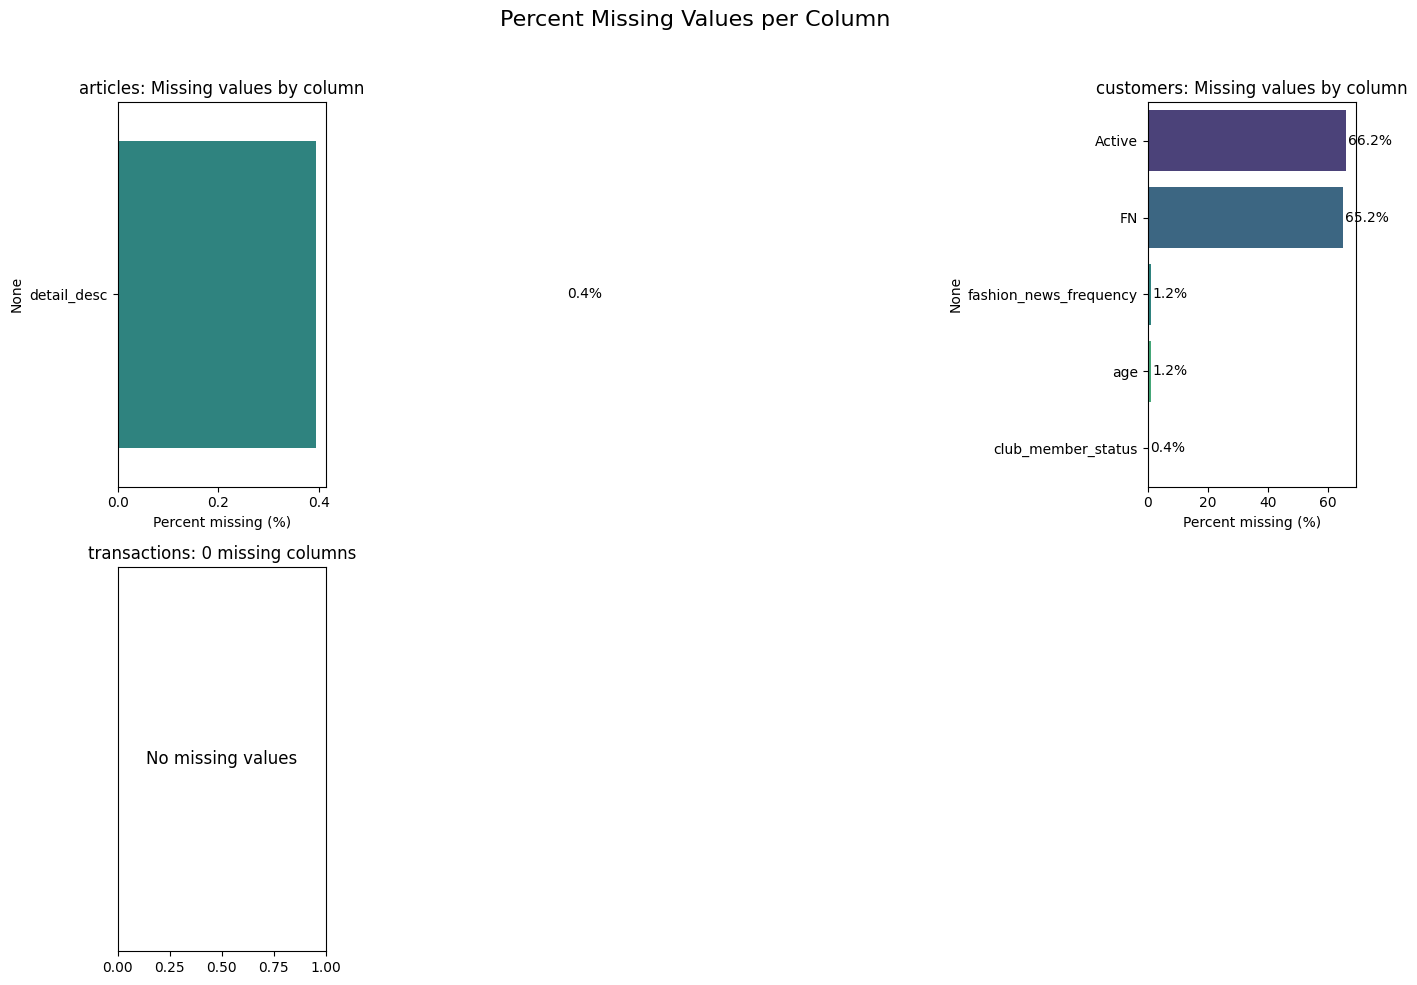

In [6]:
# Explore different datasets




articles_n_features = articles.shape[1]  
articles_n_lines = articles.shape[0]

print(f"articles dataset has {articles_n_lines} lines and {articles_n_features} features.")

customers_n_features = customers.shape[1] 
customers_n_lines = customers.shape[0]

print(f"customers dataset has {customers_n_lines} lines and {customers_n_features} features.")

transactions_n_features = transactions.shape[1] 
transactions_n_lines = transactions.shape[0]

print(f"transactions dataset has {transactions_n_lines} lines and {transactions_n_features} features.")




# Explore the NA values 
na_counts = articles.isna().sum()
print("NA values in each column of articles dataset:")
print(na_counts[na_counts > 0])

na_counts_customers = customers.isna().sum()
print("NA values in each column of customers dataset:")
print(na_counts_customers[na_counts_customers > 0])

na_counts_transactions = transactions.isna().sum()
print("NA values in each column of transactions dataset:")
print(na_counts_transactions[na_counts_transactions > 0])       



# Clearer plots for missing values: percent missing per column
datasets = {'articles': articles, 'customers': customers, 'transactions': transactions}
plt.figure(figsize=(14, 10))
for i, (name, df) in enumerate(datasets.items(), 1):
    plt.subplot(2, 2, i)
    # percent of missing values by column (0-100)
    na_pct = df.isna().mean() * 100
    na_pct = na_pct[na_pct > 0].sort_values(ascending=False)
    if na_pct.empty:
        plt.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=12)
        plt.title(f'{name}: 0 missing columns')
        plt.xlabel('')
        plt.yticks([])
    else:
        sns.barplot(x=na_pct.values, y=na_pct.index, palette='viridis')
        plt.xlabel('Percent missing (%)')
        plt.title(f'{name}: Missing values by column')
        # annotate bars with percent values
        for j, v in enumerate(na_pct.values):
            plt.text(v + 0.5, j, f'{v:.1f}%', va='center')
plt.suptitle('Percent Missing Values per Column', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [7]:
def summarize_dataframe(df):
    summary = pd.DataFrame({
        "column_name": df.columns,
        "dtype": df.dtypes.astype(str).values,  # .values pour éviter l'alignement d'index
        "example_value": [df[col].iloc[0] if len(df[col]) > 0 else None for col in df.columns],
        "n_unique": df.nunique(dropna=True),  #  Méthode vectorisée pandas - BEAUCOUP plus rapide
        "n_missing": df.isna().sum().values
    })
    return summary.reset_index(drop=True)

Feature engineering sur articles

In [8]:
articles_summary = summarize_dataframe(articles)
articles_summary

,column_name,dtype,example_value,n_unique,n_missing
0,article_id,int64,108775015,105542,0
1,product_code,int64,108775,47224,0
2,prod_name,object,Strap top,45875,0
3,product_type_no,int64,253,132,0
4,product_type_name,object,Vest top,131,0
5,product_group_name,object,Garment Upper body,19,0
6,graphical_appearance_no,int64,1010016,30,0
7,graphical_appearance_name,object,Solid,30,0
8,colour_group_code,int64,9,50,0
9,colour_group_name,object,Black,50,0


In [9]:
# Encoder index_code
le = LabelEncoder()
articles['index_code_numeric'] = le.fit_transform(articles['index_code'])

# To see the mapping:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Index code mapping:", mapping)

Index code mapping: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'F': np.int64(4), 'G': np.int64(5), 'H': np.int64(6), 'I': np.int64(7), 'J': np.int64(8), 'S': np.int64(9)}


In [10]:
# Dropping non int columns
articles = articles.select_dtypes(include=['int', 'int64', 'int32'])
print("Integer columns:", articles.columns.tolist())
print("number of colums columns:", len(articles.columns.tolist()))

Integer columns: ['article_id', 'product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'index_code_numeric']
number of colums columns: 12


Feature engineering sur customers

In [11]:
customers_summary = summarize_dataframe(customers)
customers_summary

,column_name,dtype,example_value,n_unique,n_missing
0,customer_id,object,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1371980,0
1,FN,float64,NaN,1,895050
2,Active,float64,NaN,1,907576
3,club_member_status,object,ACTIVE,3,6062
4,fashion_news_frequency,object,NONE,3,16011
5,age,float64,49.0,84,15861
6,postal_code,object,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...,352899,0


In [12]:
# si le 'club_member_status' est missing, on considère que le client n'est pas membre
customers['club_member_status'] = customers['club_member_status'].fillna('NOT_MEMBER')
# si la 'fashion_news_frequency' est missing, on considère que le client ne reçoit pas de newsletter
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')


In [13]:
# Drop les colonnes FN et Active (trop de missing)
customers = customers.drop(columns=['FN', 'Active'])

# Encode les colonnes catégorielles

le_club = LabelEncoder()
customers['club_member_status_encoded'] = le_club.fit_transform(customers['club_member_status'])

le_news = LabelEncoder()
customers['fashion_news_frequency_encoded'] = le_news.fit_transform(customers['fashion_news_frequency'])





In [14]:
# Traite postal_code (trop de valeurs uniques, on prend les 3-4 premiers chiffres)
le_customer = LabelEncoder()
customers['customer_id_encoded'] = le_customer.fit_transform(customers['customer_id'])
customer_mapping = dict(zip(customers['customer_id'], customers['customer_id_encoded']))

#customers['postal_code_prefix'] = customers['postal_code'].str[:3]
le_postal = LabelEncoder()
customers['postal_code_encoded'] = le_postal.fit_transform(customers['postal_code'])

# Traite l'âge (impute les missing avec la médiane)
customers['age'] = customers['age'].fillna(customers['age'].median())

# Garde seulement les colonnes numériques
customers_features = customers[['customer_id', 'age', 'club_member_status_encoded', 
                                 'fashion_news_frequency_encoded', 'postal_code_encoded']]

In [15]:
# Dropping non int columns
customers  = customers.select_dtypes(include=['int', 'int64', 'int32','float64'])
print("Integer columns:", customers.columns.tolist())
print("number of colums columns:", len(customers.columns.tolist()))

Integer columns: ['age', 'club_member_status_encoded', 'fashion_news_frequency_encoded', 'customer_id_encoded', 'postal_code_encoded']
number of colums columns: 5


Feature engineering for transactions

In [16]:
transactions_summary = summarize_dataframe(transactions)
transactions_summary

,column_name,dtype,example_value,n_unique,n_missing
0,t_dat,datetime64[ns],2020-08-12 00:00:00,42,0
1,customer_id,object,eb0bc03e0cef3bd511cdd3858a5273d9e8b133d94b2890...,302144,0
2,article_id,int64,888026003,31937,0
3,price,float64,0.01761,4835,0
4,sales_channel_id,int64,2,2,0


Nombre de clients uniques : 302144

Nombre moyen de transactions par client : 4.96
Médiane : 3
Min : 1, Max : 159

Top 20 articles les plus vendus :
article_id
751471001    3607
918292001    3041
706016001    3026
751471043    2883
915526001    2875
915529003    2693
896152002    2577
448509014    2550
916468003    2501
850917001    2241
863595006    2226
714790020    2124
898694001    2099
915526002    2054
706016003    1951
915529001    1912
715624001    1874
909370001    1868
852584001    1860
866731001    1837
Name: count, dtype: int64

Prix moyen : 0.03€


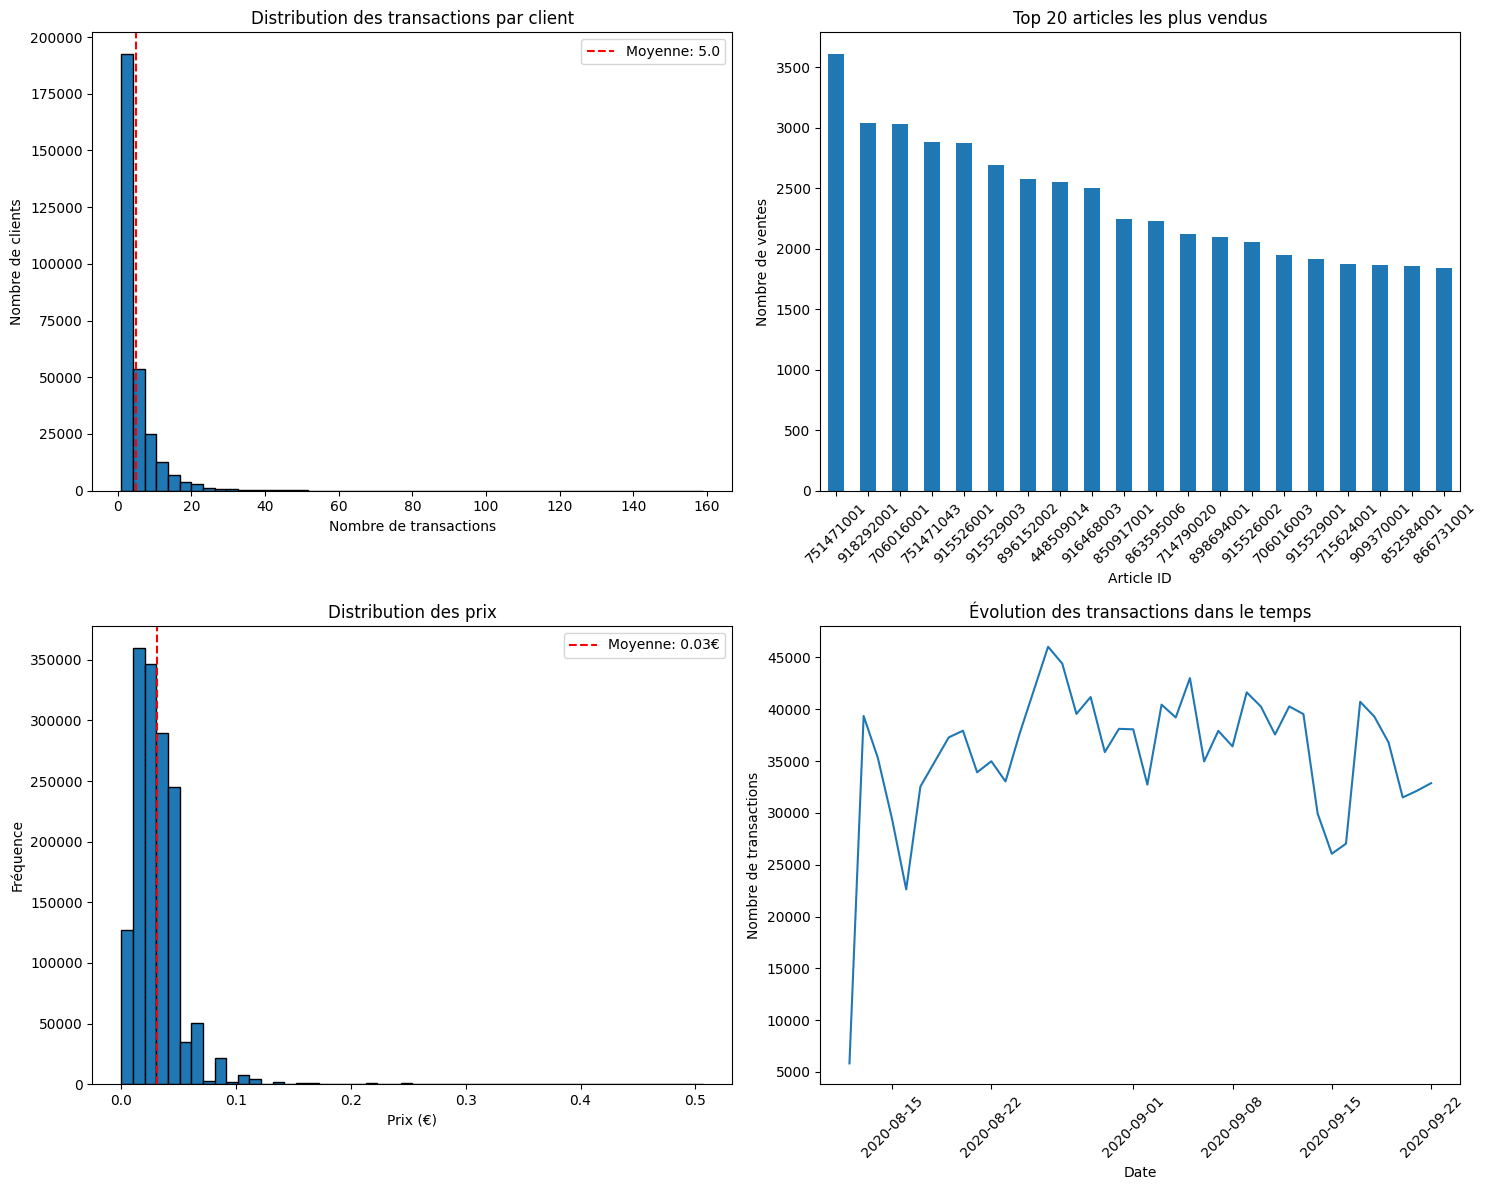


=== RÉSUMÉ STATISTIQUE ===
Nombre total de transactions : 1500000
Nombre de clients uniques : 302144
Nombre d'articles uniques : 31937
Transactions par client (moyenne) : 4.96
Prix moyen : 0.03€
Prix médian : 0.03€


In [17]:
# 1. NOMBRE DE CLIENTS UNIQUES
n_customers = transactions['customer_id'].nunique()
print(f"Nombre de clients uniques : {n_customers}")


# 2. NOMBRE DE TRANSACTIONS PAR CLIENT
transactions_per_customer = transactions.groupby('customer_id').size()
print(f"\nNombre moyen de transactions par client : {transactions_per_customer.mean():.2f}")
print(f"Médiane : {transactions_per_customer.median():.0f}")
print(f"Min : {transactions_per_customer.min()}, Max : {transactions_per_customer.max()}")

# 3. ARTICLES LES PLUS VENDUS
top_articles = transactions['article_id'].value_counts().head(20)
print(f"\nTop 20 articles les plus vendus :")
print(top_articles)

# 4. PRIX MOYEN
prix_moyen = transactions['price'].mean()
print(f"\nPrix moyen : {prix_moyen:.2f}€")

# VISUALISATIONS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique 1 : Distribution des transactions par client
axes[0, 0].hist(transactions_per_customer, bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Nombre de transactions')
axes[0, 0].set_ylabel('Nombre de clients')
axes[0, 0].set_title('Distribution des transactions par client')
axes[0, 0].axvline(transactions_per_customer.mean(), color='red', 
                    linestyle='--', label=f'Moyenne: {transactions_per_customer.mean():.1f}')
axes[0, 0].legend()

# Graphique 2 : Top 20 articles les plus vendus
top_articles.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_xlabel('Article ID')
axes[0, 1].set_ylabel('Nombre de ventes')
axes[0, 1].set_title('Top 20 articles les plus vendus')
axes[0, 1].tick_params(axis='x', rotation=45)

# Graphique 3 : Distribution des prix
axes[1, 0].hist(transactions['price'], bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Prix (€)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution des prix')
axes[1, 0].axvline(prix_moyen, color='red', 
                    linestyle='--', label=f'Moyenne: {prix_moyen:.2f}€')
axes[1, 0].legend()

# Graphique 4 : Évolution temporelle des transactions
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions_par_jour = transactions.groupby(transactions['t_dat'].dt.date).size()
axes[1, 1].plot(transactions_par_jour.index, transactions_par_jour.values)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Nombre de transactions')
axes[1, 1].set_title('Évolution des transactions dans le temps')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# STATISTIQUES COMPLÉMENTAIRES
print("\n=== RÉSUMÉ STATISTIQUE ===")
print(f"Nombre total de transactions : {len(transactions)}")
print(f"Nombre de clients uniques : {n_customers}")
print(f"Nombre d'articles uniques : {transactions['article_id'].nunique()}")
print(f"Transactions par client (moyenne) : {transactions_per_customer.mean():.2f}")
print(f"Prix moyen : {prix_moyen:.2f}€")
print(f"Prix médian : {transactions['price'].median():.2f}€")


In [18]:
# Convertir en datetime
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 1. Features temporelles classiques
transactions['year'] = transactions['t_dat'].dt.year
transactions['month'] = transactions['t_dat'].dt.month
transactions['day'] = transactions['t_dat'].dt.day
transactions['day_of_week'] = transactions['t_dat'].dt.dayofweek  # 0=Lundi, 6=Dimanche
transactions['week_of_year'] = transactions['t_dat'].dt.isocalendar().week
transactions['is_weekend'] = (transactions['day_of_week'] >= 5).astype(int)

# 2. Recency (jours depuis la date la plus récente)
reference_date = transactions['t_dat'].max()
transactions['recency_days'] = (reference_date - transactions['t_dat']).dt.days

# 3. Days since start (pour capturer les tendances temporelles)
start_date = transactions['t_dat'].min()
transactions['days_since_start'] = (transactions['t_dat'] - start_date).dt.days

# Vérifie le résultat
print("Features temporelles créées:")
print(transactions[['t_dat', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 
                    'is_weekend', 'recency_days', 'days_since_start']].head(10))

print(f"\nDataset date range: {transactions['t_dat'].min()} to {transactions['t_dat'].max()}")
print(f"Total days span: {transactions['days_since_start'].max()}")



Features temporelles créées:
       t_dat  year  month  day  day_of_week  week_of_year  is_weekend  \
0 2020-08-12  2020      8   12            2            33           0   
1 2020-08-12  2020      8   12            2            33           0   
2 2020-08-12  2020      8   12            2            33           0   
3 2020-08-12  2020      8   12            2            33           0   
4 2020-08-12  2020      8   12            2            33           0   
5 2020-08-12  2020      8   12            2            33           0   
6 2020-08-12  2020      8   12            2            33           0   
7 2020-08-12  2020      8   12            2            33           0   
8 2020-08-12  2020      8   12            2            33           0   
9 2020-08-12  2020      8   12            2            33           0   

   recency_days  days_since_start  
0            41                 0  
1            41                 0  
2            41                 0  
3            41        

In [19]:
# encodage de customer_id avec les memes codes que dans la table customers
transactions['customer_id_encoded'] = transactions['customer_id'].map(customer_mapping).fillna(-1).astype(int)


In [20]:
transactions  = transactions.select_dtypes(include=['int', 'int64', 'int32','float64','datetime64'])
print("Integer columns:", transactions.columns.tolist())
print("number of colums columns:", len(transactions.columns.tolist()))

Integer columns: ['t_dat', 'article_id', 'price', 'sales_channel_id', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'recency_days', 'days_since_start', 'customer_id_encoded']
number of colums columns: 12


Merge des 3 datasets

In [21]:
transactions_with_customers = transactions.merge(
    customers,
    on='customer_id_encoded',
    how='left',  # Garde que les transactions pour lequel on a trouvé le customer_id dans customers
    suffixes=('', '_cust')
)

print(f"Après merge customers: {transactions_with_customers.shape}")

# Merge + Articles
transactions_full = transactions_with_customers.merge(
    articles,
    on='article_id',
    how='left',
    suffixes=('', '_art')
)

print(f"\n Merge terminé: {transactions_full.shape}")
print(f"Colonnes: {len(transactions_full.columns)}")

print(f"\nMissing values après merge:")
print(transactions_full.isna().sum().sort_values(ascending=False).head(10))

Après merge customers: (1500000, 16)

 Merge terminé: (1500000, 27)
Colonnes: 27

Missing values après merge:
t_dat               0
article_id          0
price               0
sales_channel_id    0
year                0
month               0
day                 0
day_of_week         0
is_weekend          0
recency_days        0
dtype: int64


In [22]:
transactions_full.columns

Index(['t_dat', 'article_id', 'price', 'sales_channel_id', 'year', 'month',
       'day', 'day_of_week', 'is_weekend', 'recency_days', 'days_since_start',
       'customer_id_encoded', 'age', 'club_member_status_encoded',
       'fashion_news_frequency_encoded', 'postal_code_encoded', 'product_code',
       'product_type_no', 'graphical_appearance_no', 'colour_group_code',
       'perceived_colour_value_id', 'perceived_colour_master_id',
       'department_no', 'index_group_no', 'section_no', 'garment_group_no',
       'index_code_numeric'],
      dtype='object')